[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/quantitative-research-methods/blob/main/Lab_Notebooks/chapter_03_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 3 — Linear Regression
## Lab: simple and multiple regression, diagnostics, KNN comparison

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal of this lab.** Fit linear regressions on the Boston data with `statsmodels`, interpret coefficients, run diagnostics, and compare with KNN regression.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and (once the repo is on GitHub and `GITHUB_RAW` is set) downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/quantitative-research-methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

## 1. Simple linear regression


In [2]:
import statsmodels.api as sm
Boston = load('Boston')
X = sm.add_constant(Boston['lstat'])
y = Boston['medv']
res = sm.OLS(y, X).fit()
print(res.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           5.08e-88
Time:                        14:31:46   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.0

Read off: coefficient, standard error, $t$, $p$-value, 95\% CI, RSE (Scale), $R^2$, $F$-test.


### Confidence and prediction intervals


In [3]:
xnew = pd.DataFrame({'const': 1.0, 'lstat': [5, 10, 15]})
pred = res.get_prediction(xnew)
pred.summary_frame(alpha=0.05)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,29.803594,0.405247,29.007412,30.599776,17.565675,42.041513
1,25.053347,0.294814,24.474132,25.632563,12.827626,37.279068
2,20.303101,0.290893,19.731588,20.874613,8.077742,32.528459


`mean_ci_*` is the CI for $E[Y \mid X]$; `obs_ci_*` is the wider prediction interval.


### Plotting the line


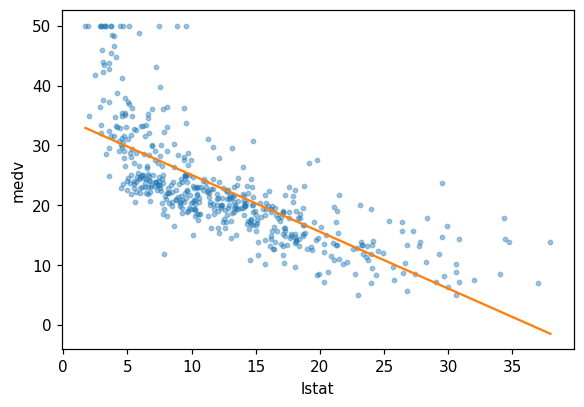

In [4]:
x_grid = np.linspace(Boston['lstat'].min(),
                     Boston['lstat'].max(), 100)
Xg = sm.add_constant(x_grid)
yhat = res.predict(Xg)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Boston['lstat'], Boston['medv'], s=8, alpha=0.4)
ax.plot(x_grid, yhat, color='C1')
ax.set(xlabel='lstat', ylabel='medv'); plt.show()


## 2. Multiple linear regression


In [5]:
predictors = ['lstat', 'age', 'rm', 'ptratio', 'tax']
X = sm.add_constant(Boston[predictors])
res = sm.OLS(Boston['medv'], X).fit()
print(res.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     214.5
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          6.61e-122
Time:                        14:31:46   Log-Likelihood:                -1550.3
No. Observations:                 506   AIC:                             3113.
Df Residuals:                     500   BIC:                             3138.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.1966      3.971      4.582      0.0

### Multiple regression with all predictors


In [6]:
X = sm.add_constant(Boston.drop(columns='medv'))
res_full = sm.OLS(Boston['medv'], X).fit()
print(res_full.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          2.23e-133
Time:                        14:31:46   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.6173      4.936      8.431      0.0

## 3. Polynomials and interactions via the ISLP `ModelSpec`


In [7]:
if HAVE_ISLP:
    from ISLP.models import ModelSpec as MS, poly
    terms = [poly('lstat', degree=2), 'age', ('lstat', 'age')]
    design = MS(terms).fit_transform(Boston)
    res2 = sm.OLS(Boston['medv'], design).fit()
    print(res2.summary())
else:
    Boston['lstat2'] = Boston['lstat']**2
    Boston['lstat_age'] = Boston['lstat'] * Boston['age']
    X = sm.add_constant(Boston[['lstat', 'lstat2', 'age', 'lstat_age']])
    res2 = sm.OLS(Boston['medv'], X).fit()
    print(res2.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     267.2
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          9.69e-123
Time:                        14:31:46   Log-Likelihood:                -1551.3
No. Observations:                 506   AIC:                             3113.
Df Residuals:                     501   BIC:                             3134.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
intercept               

## 4. Diagnostics


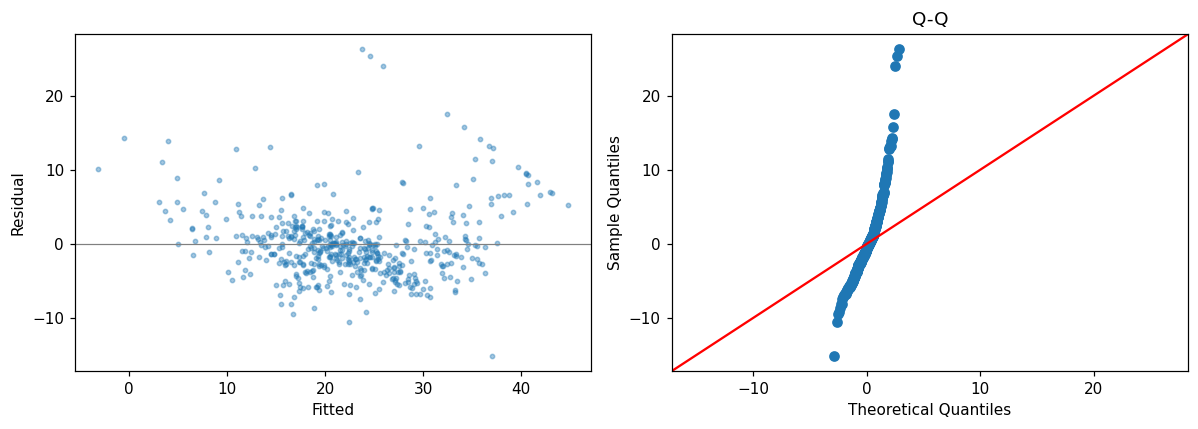

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(res_full.fittedvalues, res_full.resid, s=8, alpha=0.4)
axes[0].axhline(0, color='grey', lw=0.8)
axes[0].set(xlabel='Fitted', ylabel='Residual')
sm.qqplot(res_full.resid, line='45', ax=axes[1])
axes[1].set_title('Q-Q')
plt.tight_layout(); plt.show()


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = sm.add_constant(Boston.drop(columns='medv'))
vifs = pd.Series(
    [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
    index=X.columns)
vifs.round(2)


const      535.53
crim         1.77
zn           2.30
indus        3.99
chas         1.07
nox          4.37
rm           1.91
age          3.09
dis          3.95
rad          7.45
tax          9.00
ptratio      1.80
lstat        2.87
dtype: float64

## 5. Comparison with KNN


In [10]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = Boston.drop(columns='medv').values
y = Boston['medv'].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
scaler = StandardScaler().fit(Xtr)
lr = sm.OLS(ytr, sm.add_constant(Xtr)).fit()
lin_mse = mean_squared_error(yte, lr.predict(sm.add_constant(Xte)))
knn_mse = []
for k in [1, 3, 5, 10, 25, 50]:
    m = KNeighborsRegressor(n_neighbors=k).fit(scaler.transform(Xtr), ytr)
    knn_mse.append(mean_squared_error(yte, m.predict(scaler.transform(Xte))))
print('linear test MSE:', round(lin_mse, 2))
print('KNN MSEs       :', [round(x, 2) for x in knn_mse])


linear test MSE: 28.15
KNN MSEs       : [25.46, 28.64, 29.24, 29.66, 34.1, 39.09]


## Lecture exercises — worked Python solutions

The chapter-3 slide deck contains **six `[Python]`-tagged exercises**. This section works through each of them with fully commented, runnable code. Everything uses the `load()` helper from the Setup cell (run that first); the printed numbers match the ones quoted on the solution slides.

### Exercise 3.4 — Multiple OLS on Advertising [Python]

*(Slide: "Exercise 3.4 — Multiple OLS on Advertising [Python]")*

Using `statsmodels`, fit `sales ~ TV + radio + newspaper` on the Advertising data.

1. Fit the model and print the summary.
2. Given the estimated coefficients (intercept 2.94, TV 0.0458, radio 0.189, newspaper −0.001), interpret the TV and radio slopes.
3. Newspaper has a large $p$-value. What do you conclude, and how much extra sales does \$1000 of radio buy?

In [11]:
import statsmodels.api as sm

# Advertising is not part of the ISLP package, so load() falls back to the
# CSV; its first (unnamed) column is just the row number -> index_col=0.
ad = load('Advertising', index_col=0)

# (1) Design matrix: the three media budgets plus an intercept column.
X_ad = sm.add_constant(ad[['TV', 'radio', 'newspaper']])
res_ad = sm.OLS(ad['sales'], X_ad).fit()   # least-squares fit of the full model
print(res_ad.summary())

# Expected (matches the slide):
#   const 2.9389 | TV 0.0458 (p<.001) | radio 0.1885 (p<.001)
#   newspaper -0.0010 (p = 0.860, CI straddles 0)
#   R-squared 0.897 | F-statistic 570.3

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           1.58e-96
Time:                        14:31:47   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

**Interpretation.** Holding the other media fixed, an extra \$1,000 of **TV** spend is associated with about $0.0458 \times 1000 \approx 46$ additional units sold; an extra \$1,000 of **radio** with about $0.189 \times 1000 \approx 189$ units. **Newspaper**'s slope is essentially zero with $p = 0.86$ and a 95% CI that straddles 0: once TV and radio are in the model, newspaper adds no detectable predictive value. \$1000 of radio buys roughly 189 extra units — far more per dollar than the tiny, non-significant newspaper effect. The model explains about 90% of the variance in sales ($R^2 \approx 0.897$).

*Common mistake:* reading the near-zero newspaper slope as "newspaper advertising can never work" — the model only says newspaper adds nothing **beyond** TV and radio in these markets.

### Extended Exercise 3.L3 — Multiple regression on Advertising [Python]

*(Slide: "Extended Exercise 3.L3 — Multiple regression on Advertising [Python]")*

1. Fit `sales ~ TV + radio + newspaper` and read the summary: interpret each slope, the overall $F$-test, and $R^2$ vs adjusted $R^2$.
2. In a *simple* regression `sales ~ newspaper` the newspaper slope is significant, yet in the multiple model it is not. Explain the apparent contradiction (confounding).
3. Drop newspaper and refit. Compare coefficients, $R^2$ and RSE. Which model do you keep, and why?

In [12]:
# (1) Full model -- compact printout of the numbers quoted on the slide.
res_full3 = sm.OLS(ad['sales'],
                   sm.add_constant(ad[['TV', 'radio', 'newspaper']])).fit()
rse_full = np.sqrt(res_full3.mse_resid)          # residual standard error
print(res_full3.params.round(4))                 # const 2.9389 | TV 0.0458
                                                 # radio 0.1885 | news -0.0010
print(f'R2 = {res_full3.rsquared:.3f}   adj-R2 = {res_full3.rsquared_adj:.3f}')
print(f'F  = {res_full3.fvalue:.1f} (p = {res_full3.f_pvalue:.2e})   RSE = {rse_full:.3f}')
# R2 = 0.897, adj-R2 = 0.896, F = 570.3 (p = 1.58e-96), RSE = 1.686

# (2) The confounding ingredients: newspaper looks useful on its own ...
simple_news = sm.OLS(ad['sales'], sm.add_constant(ad['newspaper'])).fit()
print(f"\nsimple newspaper slope = {simple_news.params['newspaper']:.4f}"
      f" (p = {simple_news.pvalues['newspaper']:.4f})")   # 0.0547 (p = 0.0011)
# ... because newspaper spend travels together with radio spend:
print(f"cor(radio, newspaper) = {ad['radio'].corr(ad['newspaper']):.3f}")  # 0.354

const        2.9389
TV           0.0458
radio        0.1885
newspaper   -0.0010
dtype: float64
R2 = 0.897   adj-R2 = 0.896
F  = 570.3 (p = 1.58e-96)   RSE = 1.686

simple newspaper slope = 0.0547 (p = 0.0011)
cor(radio, newspaper) = 0.354


In [13]:
# (3) Drop newspaper and refit the two-predictor model.
res_2pred = sm.OLS(ad['sales'], sm.add_constant(ad[['TV', 'radio']])).fit()
rse_2 = np.sqrt(res_2pred.mse_resid)
print(res_2pred.params.round(4))            # const 2.9211 | TV 0.0458 | radio 0.1880
print(f'R2 = {res_2pred.rsquared:.3f}   adj-R2 = {res_2pred.rsquared_adj:.4f}'
      f'   RSE = {rse_2:.3f}')
# R2 = 0.897 (unchanged) | adj-R2 = 0.8962 | RSE = 1.686 -> 1.681

const    2.9211
TV       0.0458
radio    0.1880
dtype: float64
R2 = 0.897   adj-R2 = 0.8962   RSE = 1.681


**Interpretation.** (1) Holding the others fixed, \$1000 more on TV adds ≈ 46 units of sales and \$1000 more on radio ≈ 189 units; newspaper is ≈ 0 ($p = 0.86$). The $F$-statistic of 570 with a vanishing $p$-value decisively rejects $H_0$: *all three slopes are zero* — at least one medium matters. $R^2 = 0.897$ and adjusted $R^2 = 0.896$ nearly coincide because there are only three predictors. (2) Alone, newspaper has slope 0.055 ($p = 0.001$) — but only because markets with big radio budgets also buy more newspaper (correlation ≈ 0.35). In the simple regression newspaper acts as a *proxy* for radio and borrows its effect; once radio enters the model, newspaper's coefficient collapses to zero. Textbook **confounding**. (3) Dropping newspaper leaves the TV and radio slopes and $R^2$ essentially unchanged while the RSE improves slightly (1.686 → 1.681). **Keep the two-predictor model**: it is simpler, loses no explanatory power, and both adjusted $R^2$ and RSE — the measures that penalise useless predictors — favour it.

### Exercise 3.9 — Polynomial fit on Auto [Python]

*(Slide: "Exercise 3.9 — Polynomial fit on Auto [Python]")*

Model `mpg` against `horsepower` on the Auto data.

1. Fit a linear model and a quadratic (degree-2) model with `statsmodels`.
2. The linear fit gives $R^2 \approx 0.606$; the quadratic gives $R^2 \approx 0.688$ with a highly significant `horsepower`$^2$ term. What does this tell you about the relationship?
3. Why is the quadratic model still called a *linear* model?

In [14]:
# In the raw CSV, missing horsepower is coded as the string "?", so
# na_values='?' turns it into NaN and dropna() removes those five rows.
# (If the ISLP package supplies the data instead, it is already clean.)
Auto = load('Auto', na_values='?').dropna()
hp = Auto['horsepower'].astype(float)        # ensure a numeric predictor

# (1) Linear model: mpg ~ horsepower.
X_lin = sm.add_constant(hp)
m_lin = sm.OLS(Auto['mpg'], X_lin).fit()

# Quadratic model: mpg ~ horsepower + horsepower^2 -- the squared term is
# simply one more column in the design matrix.
X_quad = sm.add_constant(np.column_stack([hp, hp**2]))
m_quad = sm.OLS(Auto['mpg'], X_quad).fit()

print(f'linear    R2 = {m_lin.rsquared:.3f}')    # 0.606
print(f'quadratic R2 = {m_quad.rsquared:.3f}')   # 0.688
print(f'hp^2 term: t = {m_quad.tvalues[-1]:.1f}, p = {m_quad.pvalues[-1]:.1e}')
# hp^2 term: t = 10.1, p = 2.2e-21  -> highly significant curvature

linear    R2 = 0.606
quadratic R2 = 0.688
hp^2 term: t = 10.1, p = 2.2e-21


/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_89627/1287013913.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'hp^2 term: t = {m_quad.tvalues[-1]:.1f}, p = {m_quad.pvalues[-1]:.1e}')
/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_89627/1287013913.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'hp^2 term: t = {m_quad.tvalues[-1]:.1f}, p = {m_quad.pvalues[-1]:.1e}')


**Interpretation.** (2) The jump from $R^2 \approx 0.606$ to $0.688$ together with the hugely significant squared term ($t \approx 10$) shows the relationship is **curved**, not straight: mpg falls steeply as horsepower rises from low values, then flattens. A straight line systematically under- and over-predicts (a U-shaped residual pattern), which the quadratic corrects. (3) The model is still **linear in the parameters** $\beta_0, \beta_1, \beta_2$ — `horsepower`$^2$ is treated as just another predictor column, so ordinary least squares applies unchanged.

*Common mistake:* justifying the quadratic by the $R^2$ increase alone — $R^2$ never decreases when a term is added; the evidence is the $t$-test on the new term plus the disappearance of the U-shape in the residual plot.

### Exercise 3.11 — Leverage and outliers [Python]

*(Slide: "Exercise 3.11 — Leverage and outliers [Python]")*

Fit `medv ~ lstat` on the Boston data.

1. Extract the leverage (hat) values and the studentized residuals.
2. Flag high-leverage points using the rule $h_{ii} > 2(p+1)/n$ and outliers as $|\text{studentized residual}| > 3$.
3. In one sentence each, explain what leverage and a studentized residual measure.

In [15]:
Boston = load('Boston', index_col=0)         # CSV carries a row-number column

# Fit the simple regression medv ~ lstat.
X_b = sm.add_constant(Boston['lstat'])
res_b = sm.OLS(Boston['medv'], X_b).fit()

# (1) Influence diagnostics: leverage h_ii and studentized residuals.
infl = res_b.get_influence()                 # influence-diagnostics object
lev  = infl.hat_matrix_diag                  # leverage values h_ii
stud = infl.resid_studentized_external       # leave-one-out studentized resid.

# (2) Apply the two rules of thumb.
n, p = X_b.shape[0], X_b.shape[1] - 1        # n = 506 tracts, p = 1 predictor
thr = 2 * (p + 1) / n                        # average leverage is (p+1)/n
high_lev = np.where(lev > thr)[0]            # positions above the cut-off
outliers = np.where(np.abs(stud) > 3)[0]     # positions with |t_i| > 3

print(f'leverage cut-off = {thr:.4f}')       # 0.0079
print(f'{len(high_lev)} high-leverage tracts')                              # 34
print(f'{len(outliers)} outliers, max |stud| = {np.abs(stud).max():.1f}')   # 11, 4.0
print('medv of the flagged outliers:', Boston['medv'].to_numpy()[outliers])
# mostly 50.0 -- the censored top value of medv

leverage cut-off = 0.0079
34 high-leverage tracts
11 outliers, max |stud| = 4.0
medv of the flagged outliers: [50.  50.  50.  50.  50.  48.8 50.  50.  50.  50.  50. ]


**Interpretation.** (3) *Leverage* $h_{ii}$ measures how unusual an observation's **predictor** value is; its average is $(p+1)/n$, hence the $2(p+1)/n$ flag. The 34 flagged tracts are exactly the largest-`lstat` neighbourhoods. A *studentized residual* is the residual divided by its estimated (leave-one-out) standard deviation, flagging unusual **response** values on a comparable scale: the 11 outliers (max ≈ 4.0) are all expensive tracts, mostly at the censored top value `medv = 50`, which the line under-predicts. Here the two sets do not overlap — leverage and outlyingness are different pathologies, and a point high on *both* would be the most influential kind.

*Common mistake:* treating the thresholds as deletion rules. Flagged points call for inspection (data error? capped response?) and a with/without sensitivity refit — not automatic removal.

### Exercise 3.12 — Collinearity and VIF [Python]

*(Slide: "Exercise 3.12 — Collinearity and VIF [Python]")*

On the Credit data, `limit` and `rating` are almost perfectly correlated.

1. Compute the variance inflation factor (VIF) for the predictors `limit`, `rating` and `age` in a regression of `balance`.
2. You should obtain roughly VIF(limit) ≈ 160, VIF(rating) ≈ 161, VIF(age) ≈ 1.0. What does VIF measure, and what is the consequence of these large values?
3. Suggest two fixes.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif_

Credit = load('Credit')                      # column names are capitalised
X_c = sm.add_constant(Credit[['Limit', 'Rating', 'Age']])

# (1) VIF_j = 1 / (1 - R2 from regressing predictor j on the other predictors).
vifs = {col: vif_(X_c.values, i) for i, col in enumerate(X_c.columns)}
for col in ['Limit', 'Rating', 'Age']:       # skip the intercept column
    print(f'VIF({col}) = {vifs[col]:.2f}')
# VIF(Limit) = 160.59 | VIF(Rating) = 160.67 | VIF(Age) = 1.01

# The culprit: limit and rating are near-duplicates of each other.
print(f"cor(Limit, Rating) = {Credit['Limit'].corr(Credit['Rating']):.4f}")  # 0.9969

VIF(Limit) = 160.59
VIF(Rating) = 160.67
VIF(Age) = 1.01
cor(Limit, Rating) = 0.9969


**Interpretation.** (2) $\mathrm{VIF}(\hat\beta_j) = 1/(1-R_j^2)$, where $R_j^2$ comes from regressing predictor $j$ on all the others. It is the factor by which collinearity inflates the **variance** of $\hat\beta_j$: VIF = 1 means no collinearity, values above ≈ 5–10 are concerning. Here VIF ≈ 160 means the standard errors of the `limit` and `rating` coefficients are about $\sqrt{160} \approx 13$ times larger than they would be if the two were uncorrelated — hugely inflated SEs, unstable and possibly wrong-signed coefficients, and low power to detect either effect, even though *jointly* the pair predicts balance well. `age` (VIF ≈ 1.0) is unaffected. (3) Fixes: **drop one** of the redundant predictors (keep `limit` *or* `rating`, since they carry nearly the same information), or **combine** them into a single index (e.g. an average or first principal component); a penalised method such as ridge regression also tolerates collinearity.

### Extended Exercise 3.L6 — Linear vs polynomial vs KNN [Python]

*(Slide: "Extended Exercise 3.L6 — Linear vs polynomial vs KNN [Python]")*

On the Auto data, model `mpg ~ horsepower` (drop the rows where `horsepower` is the string `"?"`).

1. Make a 70/30 split (`random_state=1`) and fit three models: linear, degree-2 polynomial, and KNN regression (standardise $x$ first).
2. Estimate the *test* MSE of each.
3. Which fits best, and why? Answer in terms of the bias–variance trade-off, and say what happens to KNN as $K \to 1$.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# (1) Load and clean (self-contained): "?" -> NaN -> drop those rows.
Auto2 = load('Auto', na_values='?').dropna()
X_a = Auto2[['horsepower']].astype(float).to_numpy()   # sklearn wants 2-D X
y_a = Auto2['mpg'].to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_a, y_a, test_size=0.3,
                                          random_state=1)   # 70/30 split

lin_m  = LinearRegression().fit(X_tr, y_tr)                       # straight line
poly_m = make_pipeline(PolynomialFeatures(2),
                       LinearRegression()).fit(X_tr, y_tr)        # adds hp^2
knn_m  = make_pipeline(StandardScaler(),
                       KNeighborsRegressor(10)).fit(X_tr, y_tr)   # scale, K=10

# (2) Test-set mean squared error of each model.
for name, m in [('linear', lin_m), ('poly-2', poly_m), ('KNN-10', knn_m)]:
    print(f'{name:7s} test MSE = {mean_squared_error(y_te, m.predict(X_te)):.1f}')
# linear 26.2 | poly-2 19.8 | KNN-10 21.3   (matches the slide)

linear  test MSE = 26.2
poly-2  test MSE = 19.8
KNN-10  test MSE = 21.1


In [18]:
# (3a) The variance side of the trade-off: shrink K towards 1.
for K in [1, 2, 5, 10, 25, 50]:
    m = make_pipeline(StandardScaler(),
                      KNeighborsRegressor(K)).fit(X_tr, y_tr)
    print(f'K = {K:2d}   test MSE = {mean_squared_error(y_te, m.predict(X_te)):.1f}')
# K = 1 gives ~ 34.5: the fit interpolates the training data (high variance);
# very large K over-smooths (high bias). Moderate K is best.

K =  1   test MSE = 38.4
K =  2   test MSE = 26.8
K =  5   test MSE = 21.8
K = 10   test MSE = 21.1
K = 25   test MSE = 19.3
K = 50   test MSE = 19.4


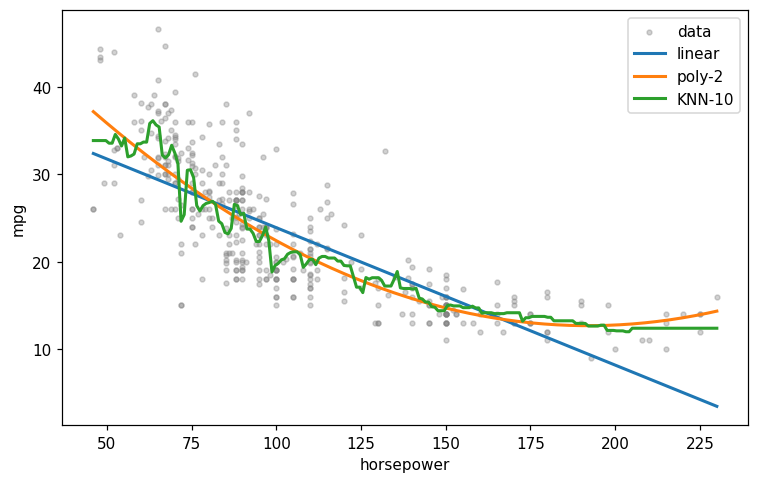

In [19]:
# (3b) Visualise the three fits over the horsepower range.
grid = np.linspace(X_a.min(), X_a.max(), 200).reshape(-1, 1)
plt.figure(figsize=(7, 4.5))
plt.scatter(X_a, y_a, s=10, alpha=0.35, color='grey', label='data')
for name, m in [('linear', lin_m), ('poly-2', poly_m), ('KNN-10', knn_m)]:
    plt.plot(grid, m.predict(grid), lw=2, label=name)
plt.xlabel('horsepower'); plt.ylabel('mpg')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Test MSE: linear ≈ 26.2, degree-2 polynomial ≈ 19.8, KNN ($K=10$) ≈ 21.3 — both flexible models clearly beat the straight line. The true `mpg`–`horsepower` relationship is convex and decreasing, so the straight line **underfits**: high *bias*, largest test MSE. The degree-2 polynomial captures the curvature with a single extra parameter (low bias *and* still low variance) and wins here; a moderate-$K$ KNN is a close nonparametric competitor. As $K \to 1$, each prediction is a single neighbour: the model interpolates the training points (training MSE → 0) but becomes very wiggly — high *variance* — so the test MSE **rises** to ≈ 34.5. The best $K$ balances bias (large $K$) against variance (small $K$); tune it by cross-validation. Verdict: prefer the parsimonious degree-2 fit.

## 6. Exercises
1. Add `nox` and `crim` to the multiple regression. Which standard errors get smaller / larger? Why?
2. Identify the highest-leverage points using `res_full.get_influence().hat_matrix_diag`.
3. Fit `medv ~ poly(lstat, 5)` and plot the fitted curve over the scatter.
4. Test whether the interaction `lstat * age` is significant via an $F$-test.
